In [ ]:
from typing import Self

import pydantic

In [ ]:
import marimo as mo

In [ ]:
import os
from pathlib import Path
from pprint import pprint
import datetime
import pandas
import altair
import highspy

# ジョブショップスケジューリング問題 (HiGHS)

問題設定や他のソルバーでの求解は `jobshop.py` を参照.

In [ ]:
parent = str(Path(os.path.abspath(__file__)).parent)
data_dir = os.path.join(parent, "data")

In [ ]:
class Task(pydantic.BaseModel):
    model_config = pydantic.ConfigDict(frozen=True)

    machine: int = pydantic.Field(..., ge=0, frozen=True)
    time: int = pydantic.Field(..., ge=0, frozen=True)

In [ ]:
class Job(pydantic.BaseModel):
    model_config = pydantic.ConfigDict(frozen=True)

    tasks: list[Task] = pydantic.Field(frozen=True)

    @classmethod
    def from_file(cls, fname: str) -> list[Self]:
        with open(fname) as f:
            n, m = None, None
            machine, proc_time = {}, {}

            i = 0
            for line in f:
                if line[0] == "#":
                    continue

                if n is None or m is None:
                    n, m = map(int, line.split())
                    print(f"{n=}, {m=}")
                    continue

                L = list(map(int, line.split()))
                for j in range(m):
                    machine[i, j] = L[2 * j]
                    proc_time[i, j] = L[2 * j + 1]
                i += 1

        jobs = []
        for i in range(n):
            tasks = []
            for j in range(m):
                tasks.append(Task(machine=machine[i, j], time=proc_time[i, j]))
            jobs.append(cls(tasks=tasks))

        return jobs

In [ ]:
def plot_altair(df: pandas.DataFrame):
    return (
        altair.Chart(df)
        .mark_bar()
        .encode(
            x="start",
            x2="end",
            y="resource",
            color="job",
        )
        .properties(width="container", height=400)
    )

In [ ]:
fname1 = os.path.join(data_dir, "ft06.txt")
jobs1 = Job.from_file(fname1)
pprint(jobs1)

n=6, m=6
[Job(tasks=[Task(machine=2, time=1), Task(machine=0, time=3), Task(machine=1, time=6), Task(machine=3, time=7), Task(machine=5, time=3), Task(machine=4, time=6)]),
 Job(tasks=[Task(machine=1, time=8), Task(machine=2, time=5), Task(machine=4, time=10), Task(machine=5, time=10), Task(machine=0, time=10), Task(machine=3, time=4)]),
 Job(tasks=[Task(machine=2, time=5), Task(machine=3, time=4), Task(machine=5, time=8), Task(machine=0, time=9), Task(machine=1, time=1), Task(machine=4, time=7)]),
 Job(tasks=[Task(machine=1, time=5), Task(machine=0, time=5), Task(machine=2, time=5), Task(machine=3, time=3), Task(machine=4, time=8), Task(machine=5, time=9)]),
 Job(tasks=[Task(machine=2, time=9), Task(machine=1, time=3), Task(machine=4, time=5), Task(machine=5, time=4), Task(machine=0, time=3), Task(machine=3, time=1)]),
 Job(tasks=[Task(machine=1, time=3), Task(machine=3, time=3), Task(machine=5, time=9), Task(machine=0, time=10), Task(machine=4, time=4), Task(machine=2, time=1)])]


## 数理最適化ソルバーによる求解

各ジョブに含まれるオペレーション数は機械の数 $m$ に一致すると仮定する.

\begin{align*}
&\min &z \\
&\text{s.t. } & s_{ij} + p_{ij} - M (1 - x_{ijkl}) &\leq s_{kl} \quad &(\forall j \ne k) \\
& & x_{ijkl} + x_{klij} &= 1 \quad &((i,j) \ne (k,l) \land \text{machine} (i,j) = \text{machine} (k,l)) \\
& & s_{ij} + p_{ij} &\le s_{i,j+1} \quad &(\forall i, j = 1, \dots, m-1) \\
& & s_{im} &\le z \quad &(\forall i) \\
& & s_{i1} &\ge 0 \quad &(\forall i) \\
& & x_{ijkl} &\in \{ 0, 1 \} \quad &(\forall (i,j) \ne (k,l))
\end{align*}

In [ ]:
class _MyInterval:
    def __init__(self, model: highspy.Highs, lb: int, ub: int, proctime: int):
        self.lb = lb
        self.ub = ub
        self.start = model.addVariable(lb=lb, ub=ub - proctime)
        self.time = proctime
        self.end = self.start + self.time


def _my_add_no_overlap(model: highspy.Highs, tasks: list[_MyInterval]) -> None:
    for idx1, task1 in enumerate(tasks):
        for idx2, task2 in enumerate(tasks):
            if idx1 >= idx2:
                continue

            big_m = max(task1.ub - task2.lb, task2.ub - task1.lb)
            tmp1 = model.addBinary()  # [ task1 ] [ task2 ] の順
            tmp2 = model.addBinary()  # [ task2 ] [ task1 ] の順
            model.addConstrs(
                [
                    task1.end - big_m * (1 - tmp1) <= task2.start,
                    task2.end - big_m * (1 - tmp2) <= task1.start,
                    tmp1 + tmp2 == 1,
                ]
            )


class ModelHighs:
    def __init__(self, jobs: list[Job]):
        self.jobs = jobs
        num_machines = len(
            set(task.machine for job in self.jobs for task in job.tasks)
        )
        self.machines = list(range(num_machines))

        self.model = highspy.Highs()

        self.intervals = [[None for task in job.tasks] for job in jobs]
        machine_to_interval = {m: [] for m in self.machines}

        horizon = sum(task.time for job in self.jobs for task in job.tasks)
        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                interval = _MyInterval(self.model, 0, horizon, task.time)
                self.intervals[id_job][id_task] = interval
                machine_to_interval[task.machine].append(interval)

        for machine in machine_to_interval:
            if len(machine_to_interval[machine]) > 0:
                _my_add_no_overlap(self.model, machine_to_interval[machine])

        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                if id_task > 0:
                    curr = self.intervals[id_job][id_task]
                    prev = self.intervals[id_job][id_task - 1]
                    self.model.addConstr(curr.start >= prev.end)

        makespan = self.model.addVariable(lb=0, ub=horizon)
        self.model.addConstrs(
            [
                self.intervals[id_job][-1].end <= makespan
                for id_job, job in enumerate(self.jobs)
            ],
        )
        self.model.minimize(makespan)

    def solve(self) -> None:
        self.model.run()
        self.solution = self.model.getSolution()

    def to_df(self) -> pandas.DataFrame:
        today = datetime.date.today()
        l = []
        for id_job, job in enumerate(self.jobs):
            for id_task, task in enumerate(job.tasks):
                start = self.solution.col_value[
                    self.intervals[id_job][id_task].start.index
                ]
                start = round(start)
                end = start + self.jobs[id_job].tasks[id_task].time
                l.append(
                    dict(
                        job=f"job{id_job}",
                        task=f"task{id_task}",
                        resource=f"machine{self.jobs[id_job].tasks[id_task].machine}",
                        start=today + datetime.timedelta(start),
                        end=today + datetime.timedelta(end),
                    )
                )
        df = pandas.DataFrame(l)
        df["start"] = pandas.to_datetime(df["start"])
        df["end"] = pandas.to_datetime(df["end"])
        return df

In [ ]:
model1_highs = ModelHighs(jobs1)
model1_highs.solve()

Running HiGHS 1.15.1 (git hash: 04024d7): Copyright (c) 2026 under MIT licence terms
Includes third-party software components, see THIRD_PARTY_NOTICES.md for full details
MIP has 306 rows; 217 cols; 792 nonzeros; 180 integer variables (180 binary)
Coefficient ranges:
  Matrix  [1e+00, 2e+02]
  Cost    [1e+00, 1e+00]
  Bound   [1e+00, 2e+02]
  RHS     [1e+00, 2e+02]
Presolving model
216 rows, 127 cols, 612 nonzeros 0s
212 rows, 127 cols, 600 nonzeros 0s
Presolve reductions: rows 212(-94); columns 127(-90); nonzeros 600(-192) 

Solving MIP model with:
   212 rows
   127 cols (90 binary, 0 integer, 0 implied int., 37 continuous, 0 domain fixed)
   600 nonzeros
   Thread count 6 (of 12 threads). Using 1 max workers. Parallel search off

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution;

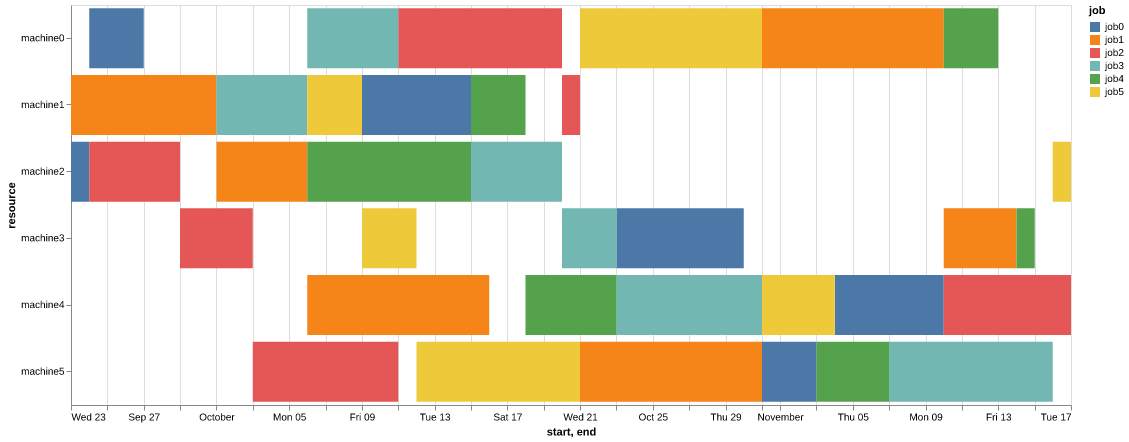

In [ ]:
plot_altair(model1_highs.to_df())